# Experiment 4: Deep Neural Network (DNN) for Digit Classification
**Student Roll Number:** `CH.SC.U4AIE24015`  



### DNN Training and Evaluation


Student Roll Number: CH.SC.U4AIE24015
Experiment 4: Deep Neural Network (DNN) on MNIST Digits
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9267 - loss: 0.2492 - val_accuracy: 0.9657 - val_loss: 0.1166
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9675 - loss: 0.1055 - val_accuracy: 0.9758 - val_loss: 0.0863
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9783 - loss: 0.0718 - val_accuracy: 0.9708 - val_loss: 0.1000
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9824 - loss: 0.0537 - val_accuracy: 0.9760 - val_loss: 0.0871
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9855 - loss: 0.0449 - val_accuracy: 0.9745 - val_loss: 0.0874

[Roll No: CH.SC.U4AIE24015] Test Accuracy: 97.41%
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--------------------------------------------------
Confusion Matrix [Roll No: CH.SC.U4AIE24015]:
[[ 965    1    3    

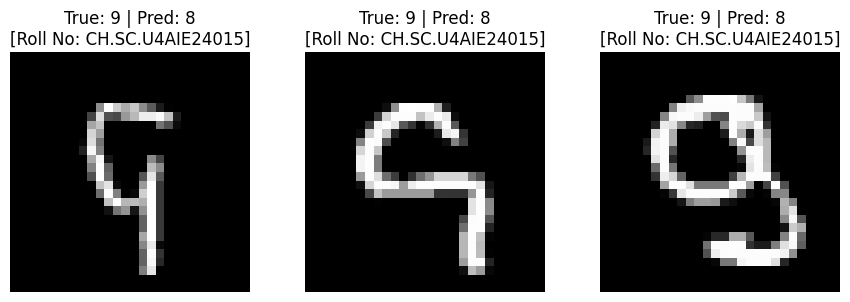

In [1]:
# Experiment 4: Deep Neural Network (DNN) for Digit Classification
# File: Exp_04_DNN_Digit_Classification_MNIST.ipynb
# Student Roll Number: CH.SC.U4AIE24015

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

print("=" * 60)
print("Student Roll Number: CH.SC.U4AIE24015")
print("Experiment 4: Deep Neural Network (DNN) on MNIST Digits")
print("=" * 60)

# Load MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Build DNN Model
model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n[Roll No: CH.SC.U4AIE24015] Test Accuracy: {test_acc * 100:.2f}%")

# Predictions & Confusion Matrix
y_pred_probs = model.predict(X_test, batch_size=64)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
print("\n" + "-" * 50)
print(f"Confusion Matrix [Roll No: CH.SC.U4AIE24015]:")
print(cm)
print("-" * 50)

# Identify & Display Misclassified Images
misclassified_idx = np.where(y_test != y_pred)[0]
print(f"\nTotal Misclassified Samples: {len(misclassified_idx)}")

plt.figure(figsize=(9, 3))
for i, idx in enumerate(misclassified_idx[:3]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}\n[Roll No: CH.SC.U4AIE24015]")
    plt.axis("off")
plt.tight_layout()
plt.show()
